# Frekvenční oblast

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Furierova řada

In [ ]:
def line(a,x,b):
    res = a*x + b
    return np.array(res)

def Bcoef(t, N):
    Bi = np.zeros_like(t)
    for n in range(1,N):
        Bi += ((2/n)*(-1)**(n+1))*np.sin(n*t)
    return np.array(Bi)

def furier(t, nMax):
    # Inicializace výsledného signálu
    res = np.zeros_like(t)
    for n in range(1, nMax):
        res += (-2/n) *np.cos(n*np.pi) *np.sin(n * t)
    return res

a = 1
b = 0


n = 200
tMax = 10000
tvec = np.linspace(-np.pi,np.pi,tMax)

line_tvec = line(a, tvec, b)
B = Bcoef(line_tvec, n)
result = furier(line_tvec, n)
plt.plot(tvec, result)
plt.plot(tvec, line_tvec)
plt.plot(tvec, B)
plt.title("Fourierova Transformace")
plt.xlabel("t")
plt.ylabel("Amplituda")
plt.grid()
plt.show()

# Furierova transformace

In [ ]:
def funk(t):
    return np.array(5+2*np.cos(2*np.pi*t-90)+3*np.cos(4*np.pi*t))


f = 4
T= 1/f
tvec = [T*i for i in range(f)]
tvec = np.array(tvec)
vals = funk(tvec)

a = np.abs(np.fft.fft(vals))
print(a)

In [ ]:
def Funkcion(A,t,f):
    w = 2*np.pi*f
    fu = A*np.sin(w*t)
    return np.array(fu)


n = 1000
A0 = 0.5
f = 50
T=1/f

tvec = np.linspace(0, np.pi, n)

myline = Funkcion(A0, tvec, f)

plt.plot(myline)
plt.show()

myline=np.abs(np.fft.fft(myline))
print(myline)
plt.plot(myline)

In [78]:
from scipy.misc import electrocardiogram
from scipy.signal import find_peaks

EKG = electrocardiogram()

Fs = 360
T = 1/Fs

n_lenght = 3840
n_lenght = 960
tvec = np.arange(n_lenght)*T
Signal = EKG[0:n_lenght]

C:\Users\micha\AppData\Local\Temp\ipykernel_16056\3452628130.py:4: DeprecationWarning: scipy.misc.electrocardiogram has been deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. Dataset methods have moved into the scipy.datasets module. Use scipy.datasets.electrocardiogram instead.
  EKG = electrocardiogram()


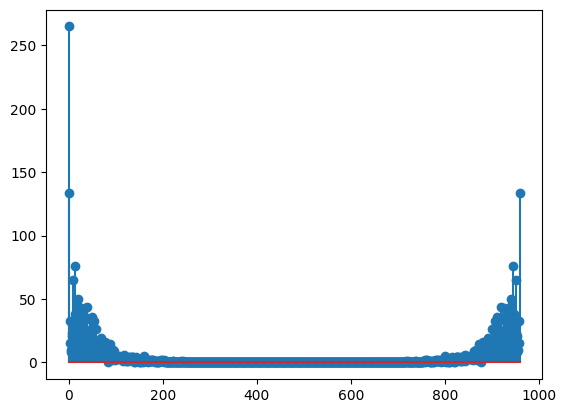

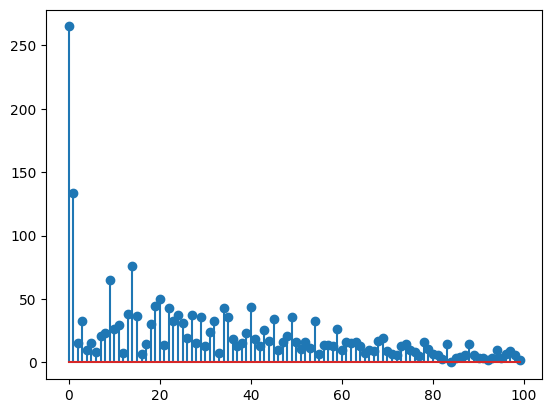

In [83]:
fft_values = np.abs(np.fft.fft(Signal))
filtered_signal = np.fft.ifft(fft_values).real 
nsig = 100
plt.stem(np.arange(tvec.size),fft_values)
plt.show()
plt.stem(np.arange(nsig),fft_values[0:nsig])
plt.show()

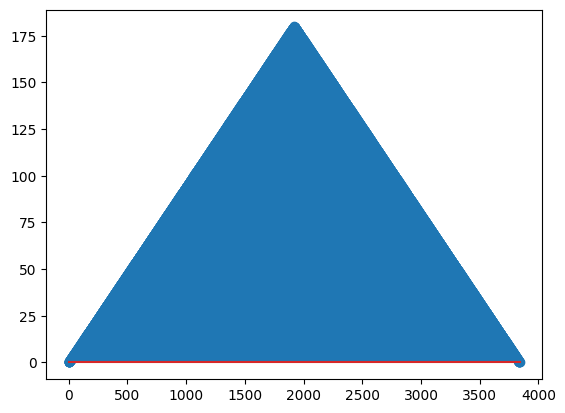

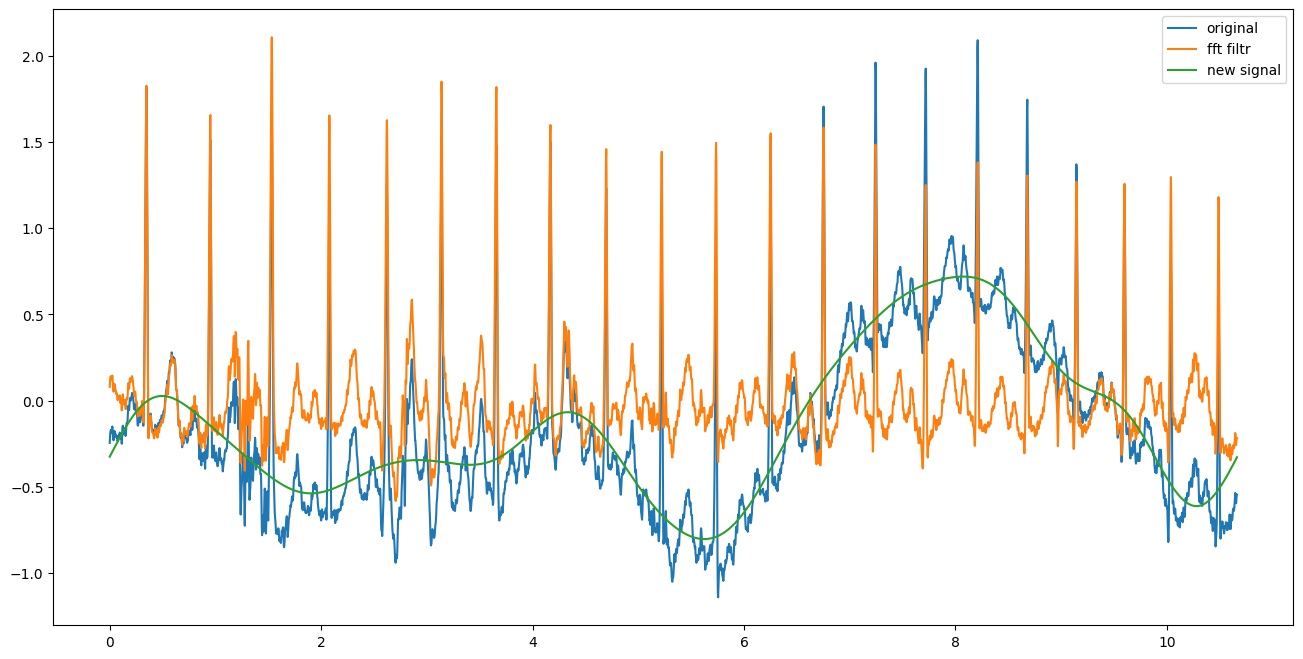

In [75]:
fft_vals = np.fft.fft(Signal)  
fft_freqs = np.fft.fftfreq(len(Signal), T)  
low_freq_threshold = 1
fft_vals[np.abs(fft_freqs) < low_freq_threshold] = 0  

a = np.abs(fft_freqs)
filtered_signal = np.fft.ifft(fft_vals).real  
new_Signal = Signal - filtered_signal

plt.stem(a)
#peaks, _ = find_peaks(Signal,height=0.5)
plt.figure(figsize=(16,8))
plt.plot(tvec,Signal, label="original")
#plt.scatter(tvec[peaks], Signal[peaks])
plt.plot(tvec, filtered_signal, label='fft filtr')
plt.plot(tvec,new_Signal, label='new signal')
plt.legend()

In [ ]:
import wave
import pyttsx3

In [ ]:
string = 'lallalalalallalalaallalala'
engine = pyttsx3.init()
engine.save_to_file(string, 'speech.wav')
engine.runAndWait()


voice = wave.open('speech.wav','rb')
wave.close()

# Digitální filtrace

* matematický proces -> selekci určité složky signálu
                        -> signál vs šum
                        -> signál1 vs signál2
* aplikace filtru -> konvoluce
                  -> rekurze (vlnková transformace) -> kaskádové

## Proces konvoluce
* -> odezva filtru (response)
* Lineární filtr
    y(t) = x(t) * h(t) --- * (konvoluce)
    -> impulzní
    -> kroková
    -> frekvenční
* impulzní odezva

## FIR, IIR (filtry)
### konvoluční filtry
- FIR (finitely long response)
### Rekurzivní filtry 
- IIR (infinitely long response)


## kroková charakteristika

## time domain parameters
* rise time
* overshoot
* linear phase
## frequency domain parameters
* low-pass
* high-pass
* band-pass
* band-reject
-----
* roll-off
* ripple
* atternuation

C:\Users\micha\AppData\Local\Temp\ipykernel_7848\3004082593.py:6: DeprecationWarning: scipy.misc.electrocardiogram has been deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. Dataset methods have moved into the scipy.datasets module. Use scipy.datasets.electrocardiogram instead.
  ECG = electrocardiogram()


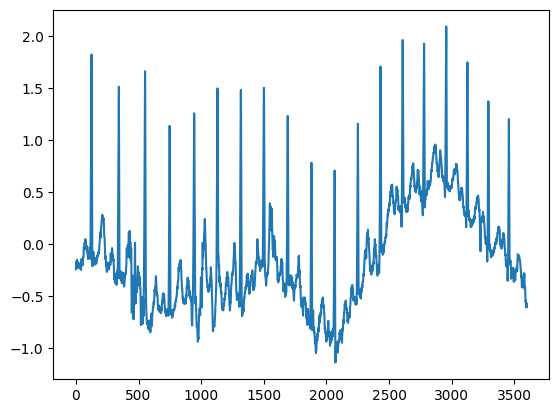

In [8]:
import matplotlib.pyplot as plt
from scipy.misc import electrocardiogram
from scipy.signal import find_peaks, convolve
import numpy as np

ECG = electrocardiogram()

Fs = 360 
tMax = 10
T = 1/Fs
n_lenght = Fs*tMax
tvec = np.arange(n_lenght)*T
ECGSample = ECG[0:n_lenght]
plt.plot(ECGSample)

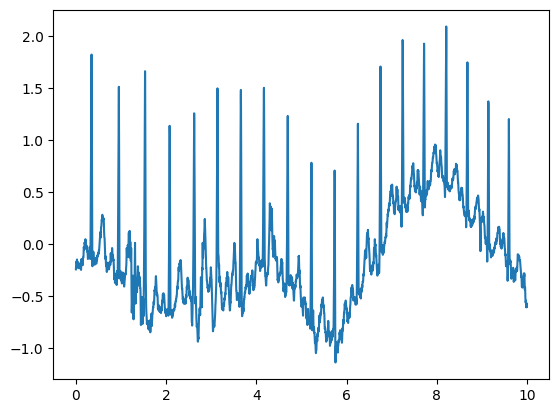

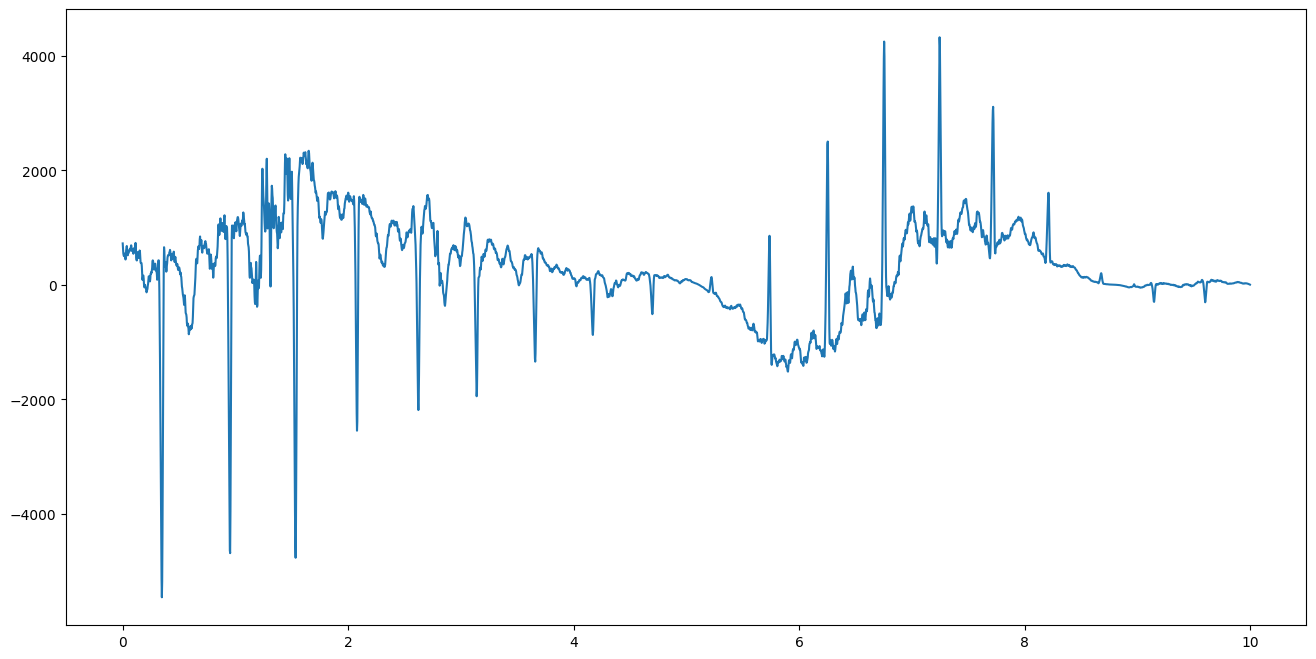

In [39]:
peaks, _ = find_peaks(ECGSample,height=0.7)
con = convolve(ECGSample,tvec)*0.7

plt.plot(tvec, ECGSample, label="original")
a = ECGSample*con[len(con)-n_lenght:len(con)]
plt.figure(figsize=(16,8))
#plt.scatter(tvec[peaks],ECGSample[peaks])
plt.plot(tvec, a)
#plt.plot(tvec, con[0:n_lenght])
plt.show()